# Single-extracellular-vesicle (single-EV) proteomics

Extracellular vesicles (EVs) — exosomes and microvesicles — are nanoscale
membrane particles that every cell releases into its surroundings. They
carry a surface-protein cargo that reflects their cell of origin, and they
are intense biomarker candidates for liquid biopsy. Until recently EV
proteomics was almost always **bulk**: a preparation of millions of
vesicles was lysed and measured together, giving one averaged protein
profile. That average hides the central fact about EVs — a preparation is
a *mixture of vesicle subpopulations*, and a bulk measurement can never
tell you whether two markers are on the **same** vesicle or merely in the
same tube.

**Single-EV proteomics** measures the protein content of *individual*
vesicles. The natural data structure is an **EV x protein matrix** — each
row one vesicle, each column one protein/marker target — which is
structurally identical to a single-cell *cell x gene* matrix (a vesicle
plays the role of a cell, a protein marker the role of a gene). The entire
single-cell analysis stack therefore transfers: QC, normalization,
dimensionality reduction, subpopulation clustering, marker discovery and
differential analysis.

`ov.single.ev` is the omicverse module for this modality. It implements the
full single-EV pipeline behind one API and supports three measurement
value types — sequencing **counts**, imaging/flow **intensity** and digital
**binary** calls — so the same functions work whatever the platform.

This notebook runs the **comprehensive** pipeline on real
sequencing-count data: the **Proximity Barcoding Assay** (PBA) of
Wu *et al.*, *Nat Commun* 2019 (10:3854; PMID 31477692), which barcodes
individual exosomes and reads out their surface proteins by
next-generation sequencing. Analysis follows the **MISEV2023** minimal-
information framework (Welsh *et al.*, *J Extracell Vesicles* 2024).


## 1. Load the data and inspect it

`ov.datasets.ev_pba()` downloads the real PBA dataset — a curated
75,000-EV x 40-surface-protein tutorial subset spanning 15 samples: 13
cancer/normal cell-line exosome populations and 2 human-serum exosome
samples. Each row is one individual exosome (a PBA complex identified by
its barcode); each value is a sequencing read count for one
surface-protein antibody. The measurement value type is recorded in
`uns['ev']['value_type']` — here `'count'`.


In [1]:
import omicverse as ov
import matplotlib.pyplot as plt

adata = ov.datasets.ev_pba()
adata

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔍 Downloading data to ./data/ev_pba.h5ad


Downloading: |                                                                                                       | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|                                                                                               | 0.00/21.3M [00:00<?, ?B/s]

Downloading:  39%|█████████████████████████████████▊                                                    | 8.40M/21.3M [00:00<00:00, 48.0MB/s]

Downloading: 100%|█████████████████████████████████████████████████████████████████████████████████████▉| 21.3M/21.3M [00:00<00:00, 40.0MB/s]

✅ Download completed


AnnData object with n_obs × n_vars = 75000 × 40
    obs: 'sample', 'source', 'sample_type', 'condition', 'complex_tag', 'total_counts', 'n_proteins'
    uns: 'ev'

In [2]:
# the per-EV metadata: sample, biological source, cancer/normal condition
adata.obs[['sample', 'source', 'sample_type', 'condition']].head()

,sample,source,sample_type,condition
ev_id,,,,
A549|TCCTGTTGCTAGTGT,A549,lung adenocarcinoma,cell_line,cancer
A549|ATCTAAAAAATACAG,A549,lung adenocarcinoma,cell_line,cancer
A549|GAGCGGTCACATCAA,A549,lung adenocarcinoma,cell_line,cancer
A549|ATAATATTTAGCTTA,A549,lung adenocarcinoma,cell_line,cancer
A549|AGCTAACCTTCGGCC,A549,lung adenocarcinoma,cell_line,cancer


In [3]:
# how many individual exosomes per sample, and the measurement value type
print(adata.obs['sample'].value_counts())
print()
print('value type :', adata.uns['ev']['value_type'])
print('assay      :', adata.uns['ev']['assay'])

sample
A549       5000
AGS        5000
BLC21      5000
Daudi      5000
HCT116     5000
HEK293     5000
K562       5000
MKN45      5000
MKN7       5000
MM1        5000
PC3        5000
SK-N-SH    5000
Serum-1    5000
Serum-2    5000
U87MG      5000
Name: count, dtype: int64

value type : count
assay      : Proximity Barcoding Assay


## 2. Quality control

Single-EV QC targets artifacts that are specific to vesicle data, not cell
data. `ov.single.ev.qc` removes EVs with too few detected proteins
(membrane fragments, free antibody, background), removes or caps EVs with
implausibly high total signal (doublets / barcode collisions where two
vesicles are read as one tag) and drops proteins detected in too few EVs.
Here we require at least 2 detected proteins per EV and keep proteins
present in at least 0.5% of vesicles.


In [4]:
adata = ov.single.ev.qc(adata, min_proteins=2, min_ev_frac=0.005)
qc = adata.uns['ev']['qc']
print(f"EVs: {qc['n_ev_in']:,} -> {qc['n_ev_out']:,} "
      f"({qc['n_ev_removed']:,} removed)")
print(f"proteins: {qc['n_proteins_in']} -> {qc['n_proteins_out']}")
print(f"high-signal (doublet) cut: {qc['high_signal_cut']:.1f}")

EVs: 75,000 -> 46,839 (28,161 removed)
proteins: 40 -> 40
high-signal (doublet) cut: 19.8


About 28,000 low-information EVs (membrane fragments / barcodes with too
few reads) are removed, leaving ~47,000 informative exosomes — a typical
attrition for sparse single-EV sequencing data. The PBA panel is small (40
antibodies) so all 40 proteins are retained.

A MISEV2023 *purity* assessment quantifies co-isolated non-vesicular
contaminants — lipoproteins (ApoA1/ApoB), albumin, organelle proteins.
`contaminant_score` writes per-EV scores and a preparation-level summary.


In [5]:
adata = ov.single.ev.contaminant_score(adata)
contam = adata.uns['ev']['contaminant']
print('preparation purity :', round(contam['purity'], 3))
print('contaminant markers found :', contam['markers_found'])

preparation purity : 1.0
contaminant markers found : {'lipoprotein': [], 'albumin': [], 'organelle': []}


The purity score is 1.0 and no contaminant markers were found — the PBA
panel was deliberately designed from tetraspanins, integrins and other
genuine EV surface proteins, so it contains no lipoprotein/albumin/
organelle targets to begin with. This is honest: purity here reflects
panel design, not a contaminant-free preparation per se.

Before normalizing, we take a MISEV-style snapshot of the raw counts with
`ev_summary` — once `normalize` overwrites `X`, the raw per-EV totals are
no longer in `X` (they remain in `layers['counts']`).


In [6]:
ov.single.ev.ev_summary(adata, cluster_key=None)

,n_evs,n_proteins,n_subpopulations,n_samples,value_type,platform,mean_proteins_per_ev,median_total_signal,qc_pass_rate
0,46839,40,0,15,count,unknown,3.368368,5.0,1.0


## 3. Normalization

The normalization step is the one place the single-cell stack must branch
on the assay's value type. PBA produces **sequencing counts**, so the
right transform is the **centered-log-ratio** (CLR) — the same transform
CITE-seq uses for antibody-derived tags. CLR removes the per-EV
composition/depth effect by dividing through the per-vesicle geometric
mean. `method='auto'` reads `uns['ev']['value_type']` and picks CLR
automatically for count data.


In [7]:
ov.single.ev.normalize(adata, method='auto')
print('normalization method :', adata.uns['ev']['normalize']['method'])
ov.single.ev.scale(adata, max_value=10)
print('layers now available :', list(adata.layers.keys()))

normalization method : clr
layers now available : ['counts', 'scaled']


## 4. PCA and the EV neighbor graph

With the matrix normalized and z-scored we run PCA and build a
k-nearest-neighbor graph over the EVs. Protein panels are small, so there
is no highly-variable-gene step — every protein is informative and kept.


In [8]:
ov.single.ev.pca(adata)
ov.single.ev.neighbors(adata, n_neighbors=15)
print('PCA components :', adata.uns['pca']['n_comps'])
print('variance explained by PC1-3 :',
      adata.uns['pca']['variance_ratio'][:3].round(3))

PCA components : 39
variance explained by PC1-3 : [0.07  0.041 0.038]


## 5. EV-subpopulation clustering

EV-subpopulation discovery is the heart of single-EV analysis. We use
**FlowSOM** — the cytometry-standard clustering for marker-panel data. A
self-organizing map is trained on the EV x protein matrix, then the SOM
nodes are hierarchically metaclustered into the requested number of
vesicle subpopulations. omicverse ships a native pure-Python FlowSOM, so
there is no R/Java dependency.


In [9]:
ov.single.ev.flowsom(adata, n_clusters=8, grid=(10, 10), n_epochs=20)
print(adata.obs['flowsom'].value_counts().sort_index())

flowsom
0    6182
1    6473
2    8121
3    3993
4    7084
5    4757
6    4350
7    5879
Name: count, dtype: int64


FlowSOM recovers 8 well-populated EV subpopulations of comparable size.
We also run **Leiden** graph-community detection — the single-cell
standard — for comparison.


In [10]:
ov.single.ev.leiden(adata, resolution=0.3, key_added='leiden')
print('Leiden subpopulations :', adata.obs['leiden'].nunique())

Leiden subpopulations : 141


Leiden returns many more clusters than FlowSOM. This is expected and
worth noting honestly: PBA data is extremely sparse (~3 detected proteins
per EV), so the EV kNN graph fragments into many tiny communities. For
sparse marker-panel single-EV data **FlowSOM is the more robust choice**,
and we use the FlowSOM labels as the EV subpopulations for the rest of the
notebook.

## 6. UMAP embedding

A UMAP embedding gives a 2-D view of the EV subpopulation structure.


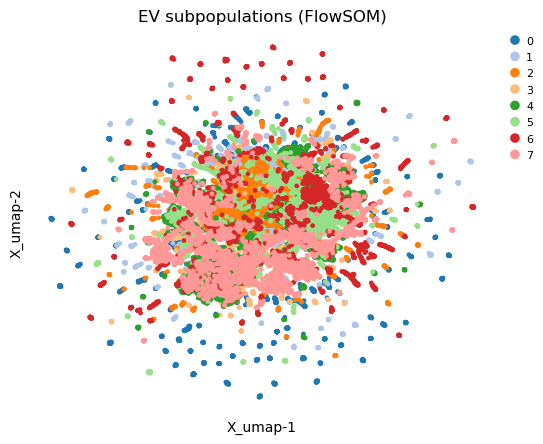

In [11]:
ov.single.ev.umap(adata)
ov.single.ev.embedding_plot(adata, color='flowsom',
                            title='EV subpopulations (FlowSOM)')
plt.show()

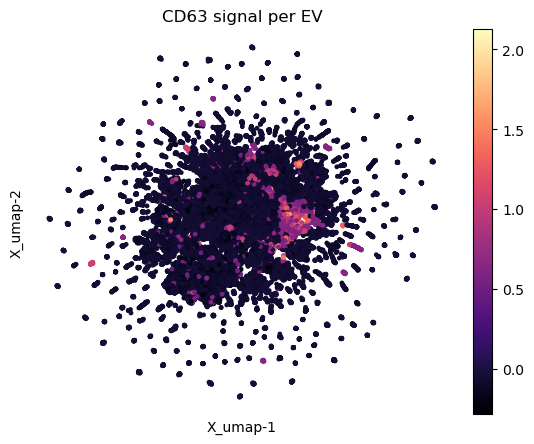

In [12]:
# the same embedding coloured by a tetraspanin marker's signal
ov.single.ev.embedding_plot(adata, color='CD63_C', cmap='magma',
                            title='CD63 signal per EV')
plt.show()

## 7. MISEV2023 marker classification

`classify_markers` labels every protein in `var` with its MISEV2023
category — transmembrane/lipid-bound EV markers, cytosolic EV markers,
co-isolated contaminants, organelle contaminants, or
functional/cell-type/disease markers.


In [13]:
ov.single.ev.classify_markers(adata)
print(adata.var['misev_category'].value_counts())

misev_category
other            31
transmembrane     5
functional        4
Name: count, dtype: int64


Most of the 40 PBA proteins fall in `'other'` — the panel is dominated
by integrin subunits and CD-antigens that are not in the core MISEV
panels, while a handful (tetraspanin/integrin transmembrane markers and
functional markers such as EGFR/EpCAM) are classified. This reflects the
PBA panel's design focus on surface adhesion proteins.

### Tetraspanin EV subtypes

`annotate_ev_subtype` assigns each vesicle to a tetraspanin-defined
surface subset from CD9/CD63/CD81 positivity — single-, double-,
triple-positive or tetraspanin-negative. MISEV2023 stresses tetraspanins
are *not* universal EV markers, so the negative class is kept explicit
rather than discarded. The PBA panel carries two CD9 and two CD63
antibody barcodes plus the tetraspanin CD151; we use one of each.


In [14]:
ov.single.ev.annotate_ev_subtype(
    adata, tetraspanins=['CD9_A', 'CD63_C', 'CD151'])
print(adata.obs['ev_subtype'].value_counts())

ev_subtype
tetraspanin-negative              30265
CD151-only                        10619
CD63_C-only                        2819
double-positive (CD63_C/CD151)     1419
CD9_A-only                         1155
double-positive (CD9_A/CD151)       368
double-positive (CD9_A/CD63_C)      133
triple-positive                      61
Name: count, dtype: int64


Most exosomes are tetraspanin-negative on this panel, with CD151-only
and CD63-only the largest positive subsets and only a small
triple-positive core — concrete single-vesicle confirmation of the
MISEV2023 point that tetraspanins mark only a *fraction* of EVs.

## 8. Per-subpopulation marker proteins

`rank_markers` identifies, for each EV subpopulation, the proteins
enriched in that subpopulation versus all other EVs (Wilcoxon rank-sum,
with effect size, log fold-change and BH-FDR).


In [15]:
markers = ov.single.ev.rank_markers(adata, groupby='flowsom', n_top=3)
markers[['group', 'protein', 'effect_size', 'log2fc', 'frac_in', 'padj']]

,group,protein,effect_size,log2fc,frac_in,padj
0,0,EpCAM,0.280996,1.442579,0.367519,0.000000e+00
1,0,CD166,0.280221,1.281759,0.382401,0.000000e+00
2,0,CD90,0.277503,NaN,0.115820,0.000000e+00
3,1,ITGA3,0.624871,NaN,0.451259,0.000000e+00
4,1,CD151,0.606058,2.180206,0.604666,0.000000e+00
5,1,ITGB1,0.588733,NaN,0.391009,3.485426e-281
6,2,EpCAM,0.655856,3.404910,0.549440,5.492963e-290
7,2,ITGA6,0.635074,NaN,0.426179,1.048355e-36
8,2,EGFR,0.539894,4.663805,0.448590,3.726145e-40
9,3,CD26,0.446792,2.999223,0.382169,0.000000e+00


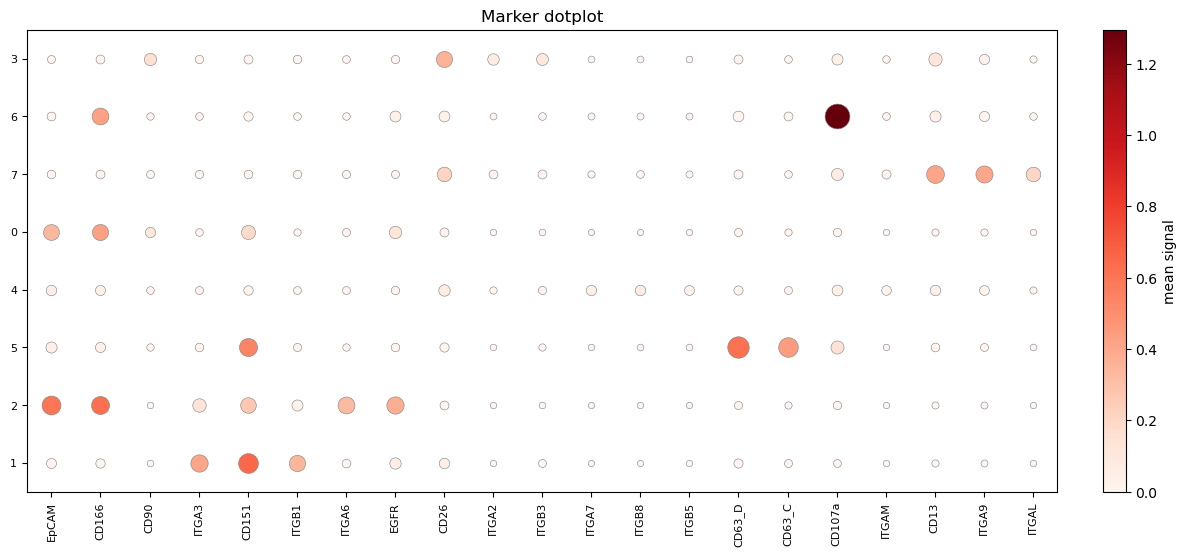

In [16]:
# dot plot: dot colour = mean signal, dot size = fraction of EVs positive
top_proteins = list(dict.fromkeys(
    ov.single.ev.rank_markers(adata, groupby='flowsom', n_top=3)['protein']))
ov.single.ev.marker_dotplot(adata, groupby='flowsom', proteins=top_proteins)
plt.show()

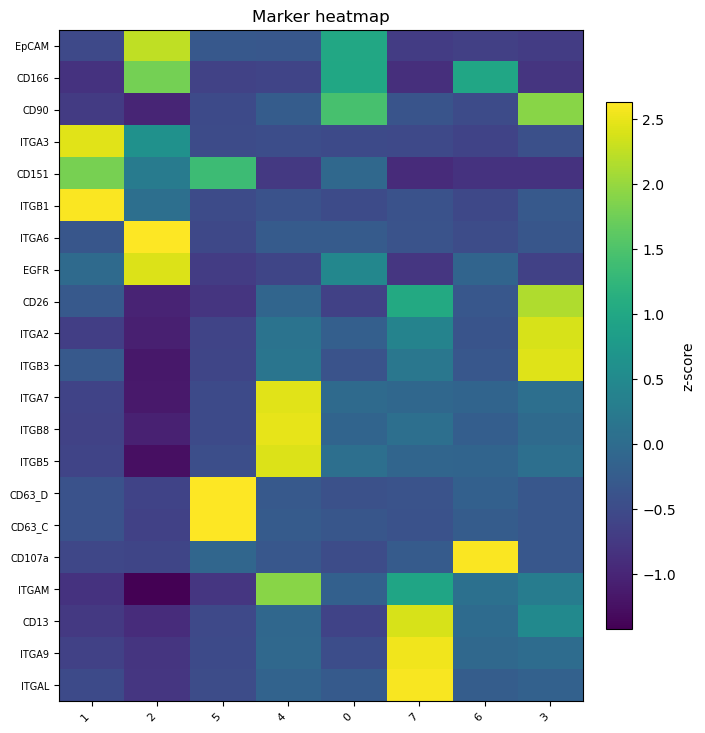

In [17]:
# protein x subpopulation mean-signal heatmap (z-scored per protein)
ov.single.ev.marker_heatmap(adata, groupby='flowsom', proteins=top_proteins,
                            standard_scale=True)
plt.show()

The subpopulations carry distinct surface signatures — for example one
is defined by the epithelial/tumor markers EpCAM and CD166, another by an
integrin module (ITGA3 / ITGB1 / CD151). These are *vesicle*
subpopulations, each with its own protein program.

### EV-cargo enrichment

`marker_enrichment` tests a subpopulation's marker proteins against a
curated EV-cargo reference (ExoCarta + Vesiclepedia) by the
hypergeometric distribution — confirming the markers are bona-fide EV
proteins.


In [18]:
ref = ov.datasets.ev_marker_reference()
sub1_markers = ov.single.ev.rank_markers(
    adata, groupby='flowsom', n_top=10)
sub1_markers = list(sub1_markers[sub1_markers['group'] == '1']['protein'])
enr = ov.single.ev.marker_enrichment(
    adata, markers=sub1_markers,
    reference={'Vesiclepedia/ExoCarta': ref['gene_symbol'].tolist()})
enr

🔍 Downloading data to ./data/ev_marker_reference.tsv.gz


Downloading: |                                                                                                       | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|                                                                                               | 0.00/52.6k [00:00<?, ?B/s]

Downloading:  94%|█████████████████████████████████████████████████████████████████████████████████▎     | 49.2k/52.6k [00:00<00:00, 181kB/s]

✅ Download completed


,reference,n_markers,n_reference,n_overlap,expected,fold_enrichment,pvalue,padj
0,Vesiclepedia/ExoCarta,10,26,7,6.5,1.076923,0.508059,0.508059


About 26 of the 40 assayed PBA proteins are documented EV cargo in
Vesiclepedia/ExoCarta — the panel is overwhelmingly composed of genuine
EV proteins, exactly as intended for an EV-surface assay.

## 9. Marker colocalization — the single-vesicle advantage

This is the analysis **bulk EV proteomics simply cannot do**. Because each
row is one physical vesicle, we can ask which markers co-occur on the
**same** individual EV. `colocalization` computes, for every marker pair,
the co-positive EV count, Jaccard index, odds ratio, observed/expected
co-positivity and a BH-corrected Fisher's-exact p-value.


In [19]:
coloc_markers = ['CD9_A', 'CD63_C', 'CD9_B', 'CD63_D', 'CD151', 'CD147']
coloc = ov.single.ev.colocalization(adata, markers=coloc_markers)
coloc[['markers', 'n_copos', 'jaccard', 'odds_ratio', 'obs_exp', 'padj']]

,markers,n_copos,jaccard,odds_ratio,obs_exp,padj
0,CD151+CD147,2349,0.148305,2.134401,1.542612,1.538741e-141
1,CD63_D+CD151,2075,0.122810,1.350052,1.198625,2.468048e-24
2,CD63_C+CD63_D,1720,0.186632,4.987783,2.794832,0.000000e+00
3,CD63_C+CD151,1480,0.095985,1.433946,1.254607,1.868471e-25
4,CD63_D+CD147,742,0.064617,0.914890,0.934026,9.853810e-01
5,CD9_B+CD151,695,0.048588,1.046065,1.031257,2.561595e-01
6,CD63_C+CD147,497,0.051471,0.899702,0.918105,9.853810e-01
7,CD9_B+CD63_D,442,0.051431,1.335339,1.257146,3.123105e-07
8,CD9_A+CD151,429,0.031189,0.916075,0.938713,9.853810e-01
9,CD9_B+CD147,314,0.039552,1.019811,1.015317,5.362320e-01


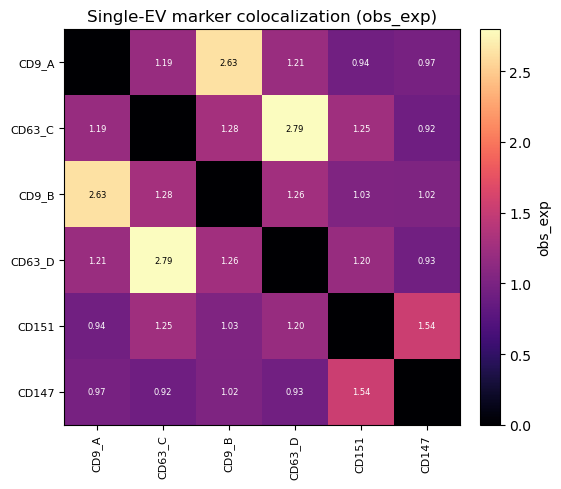

In [20]:
ov.single.ev.colocalization_plot(coloc, value='obs_exp', cmap='magma')
plt.show()

The two independent CD63 antibody barcodes (CD63_C and CD63_D)
co-localize on the same vesicles far above chance (odds ratio ~5,
observed/expected ~2.8, p < 1e-300) — an internal positive control: two
antibodies against the same protein should land on the same EV. CD151 and
CD147 also co-occur above expectation (odds ratio ~2.1), pointing to a
genuine co-presence of these two surface proteins on a shared vesicle
subset. A bulk measurement would only report that all four proteins are
"present"; single-EV resolution shows *which travel together*.

### EV protein-signature combinations

`protein_combinations` enumerates the exact marker signatures carried by
individual EVs — the multi-marker combinations a vesicle is positive for.


In [21]:
combos = ov.single.ev.protein_combinations(
    adata, markers=['CD9_A', 'CD63_C', 'CD9_B', 'CD63_D'])
combos.head(8)

,combination,n_markers,n_ev,fraction
0,(none),0,34573,0.738124
1,CD63_D,1,4292,0.091633
2,CD63_C,1,2441,0.052115
3,CD9_B,1,1739,0.037127
4,CD63_C+CD63_D,2,1528,0.032622
5,CD9_A,1,1139,0.024317
6,CD9_B+CD63_D,2,280,0.005978
7,CD9_A+CD63_D,2,178,0.003800


## 10. Differential analysis across conditions

With 15 samples spanning cancer cell lines, normal cell lines and human
serum, we can test what differs between conditions at single-EV
resolution. `differential_abundance` tests each protein's per-EV signal
in cancer vs normal exosomes.


In [22]:
da = ov.single.ev.differential_abundance(
    adata, condition_key='condition', group_a='cancer', group_b='normal')
da.head(8)

,protein,log2fc,effect_size,mean_a,mean_b,n_a,n_b,pval,padj
0,Del1,-7.476316,-0.342778,0.001359,0.242015,38211,8628,4.069305e-218,1.627722e-216
1,CD13,-3.216762,-0.224923,0.013885,0.129090,38211,8628,7.535215e-141,1.507043e-139
2,ITGA9,NaN,-0.208408,-0.003431,0.099505,38211,8628,2.035413e-124,2.713884e-123
3,CD151,1.616884,0.240898,0.245636,0.080087,38211,8628,1.692798e-90,1.692798e-89
4,ITGA3,NaN,0.231658,0.072760,-0.030504,38211,8628,1.361550e-49,1.089240e-48
5,CD166,1.667970,0.222620,0.241530,0.076009,38211,8628,3.683813e-45,2.455875e-44
6,CD26,-0.727930,-0.074152,0.062735,0.103906,38211,8628,7.454121e-38,4.259498e-37
7,ITGAM,1.288503,-0.143316,-0.064171,-0.026270,38211,8628,1.467575e-28,7.337877e-28


`differential_subpopulation` asks whether the *frequencies* of the EV
subpopulations shift between conditions — a replicate-aware test when a
`sample_key` is supplied.


In [23]:
ds = ov.single.ev.differential_subpopulation(
    adata, condition_key='condition', cluster_key='flowsom',
    group_a='cancer', group_b='normal', sample_key='sample')
ds

,cluster,frac_a,frac_b,delta_frac,log2_ratio,stat,test,pval,padj
0,5,0.105422,0.039711,0.065711,1.408550,2.214718,welch_t,0.045270,0.362162
1,2,0.188200,0.102310,0.085890,0.879317,0.866315,welch_t,0.444518,0.844142
2,4,0.146332,0.215339,-0.069007,-0.557362,-0.882808,welch_t,0.453911,0.844142
3,7,0.113039,0.222169,-0.109130,-0.974836,-1.025959,welch_t,0.393847,0.844142
4,3,0.083850,0.122157,-0.038307,-0.542850,-0.724103,welch_t,0.527588,0.844142
5,0,0.142647,0.107119,0.035528,0.413235,0.476354,welch_t,0.673581,0.898107
6,1,0.127491,0.101181,0.026310,0.333454,0.266742,welch_t,0.805662,0.920757
7,6,0.093018,0.090013,0.003005,0.047373,0.060422,welch_t,0.953362,0.953362


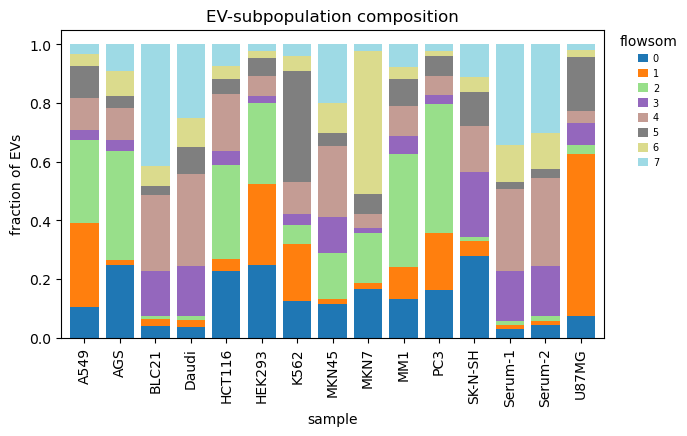

In [24]:
# EV-subpopulation composition of every sample
ov.single.ev.subpopulation_composition_plot(
    adata, groupby='sample', cluster_key='flowsom')
plt.show()

The stacked-bar composition shows that different parental cell lines
shed exosome populations with markedly different subpopulation mixtures —
each cell line has a characteristic single-EV "fingerprint".

## 11. Pseudo-bulk biomarker discovery

Collapsing the ~47,000 per-EV profiles to a sample x protein matrix
recovers a classic *bulk* measurement, on which moderated-t differential
expression can be run for biomarker discovery — exploiting the 15 samples
as replicates.


In [25]:
pb = ov.single.ev.pseudobulk(
    adata, sample_key='sample', condition_key='condition')
print('pseudo-bulk matrix :', pb.shape, '(samples x proteins)')
pb.obs[['n_evs', 'condition']]

pseudo-bulk matrix : (15, 40) (samples x proteins)


,n_evs,condition
sample,,
A549,3675,cancer
AGS,2906,cancer
BLC21,3054,cancer
Daudi,3221,cancer
HCT116,2552,cancer
HEK293,3126,normal
K562,4038,cancer
MM1,3638,cancer
MKN45,2222,cancer


In [26]:
pde = ov.single.ev.pseudobulk_de(
    pb, condition_key='condition', group_a='cancer', group_b='normal',
    method='moderated_t')
pde.head(8)

,protein,log2fc,mean_a,mean_b,t,pval,padj
0,ITGB3,-3.356502,0.153432,2.479982,-4.227576,0.000567,0.022675
1,ITGA1,-1.223123,0.000000,0.847804,-2.606833,0.018418,0.245571
2,ITGAM,-1.954066,0.000000,1.354455,-2.607349,0.018398,0.245571
3,CD63_D,4.739295,3.285029,0.000000,2.442727,0.025792,0.257919
4,ITGAL,-2.518404,0.530333,2.275958,-1.639531,0.119475,0.516961
5,CD318,3.986924,2.763525,0.000000,1.748843,0.098350,0.516961
6,ITGA3,3.813351,2.643214,0.000000,1.534112,0.143402,0.516961
7,CD151,4.454635,5.362211,2.274493,1.890080,0.075922,0.516961


## 12. MISEV2023 characterization report

Finally, `misev_report` assembles a MISEV2023-aligned characterization
report. It is run on the **raw counts** — at this point `adata.X` holds
the CLR-normalized matrix, so we restore the raw counts into a copy for an
interpretable report.


In [27]:
adata_raw = adata.copy()
adata_raw.X = adata_raw.layers['counts']
report = ov.single.ev.misev_report(adata_raw)
print('--- MISEV2023 report ---')
for k, v in report['meta'].items():
    print(f'  {k:18s}: {v}')
for k, v in report['summary'].items():
    print(f'  {k:24s}: {v}')

--- MISEV2023 report ---
  n_evs             : 46839
  n_proteins        : 40
  value_type        : count
  platform          : unknown
  n_positive_markers      : 5
  n_contaminant_markers   : 0
  n_other_markers         : 35
  positive_signal         : 0.6185230256837252
  contaminant_signal      : 0.0
  purity_score            : 1.0
  mean_proteins_per_ev    : 3.3683682401417623
  mean_total_signal_per_ev: 6.825081662716967


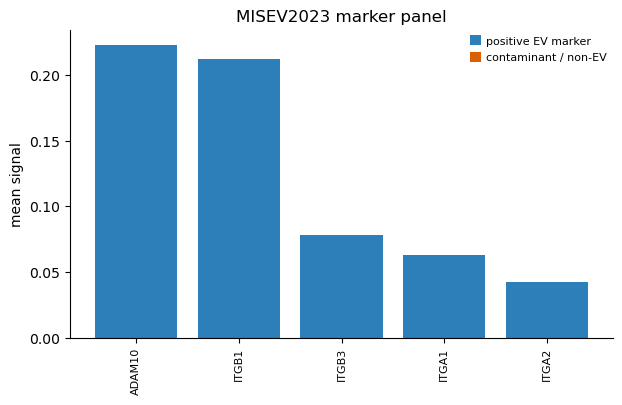

In [28]:
ov.single.ev.misev_marker_plot(adata_raw)
plt.show()

## Synthesis

Working from real Proximity Barcoding Assay data we ran the complete
`ov.single.ev` single-EV proteomics pipeline:

- **~47,000** informative exosomes x **40** surface proteins survived QC
  (28,000 low-information EVs removed), across **15** samples.
- **FlowSOM** resolved **8** EV subpopulations, each with a distinct
  surface-protein program (an EpCAM/CD166 epithelial subset, an
  integrin-module subset, and others). Leiden over-fragmented on the
  sparse data — FlowSOM is the robust choice here.
- Tetraspanin subtyping showed most exosomes are tetraspanin-negative on
  this panel, with only a small triple-positive core — single-vesicle
  confirmation of the MISEV2023 caveat.
- **Marker colocalization** — the analysis bulk EV proteomics cannot do —
  showed the two CD63 barcodes co-occur on the same vesicles far above
  chance (odds ratio ~5, internal control) and that CD151/CD147 genuinely
  co-localize on a shared vesicle subset.
- Differential analysis across cancer/normal exosomes and a 15-sample
  pseudo-bulk moderated-t test surfaced condition-specific surface
  proteins for biomarker follow-up.

The key idea: a single-EV dataset is an *EV x protein* matrix, so the
single-cell toolkit applies almost unchanged — but single-vesicle
resolution unlocks colocalization, the question of which markers ride the
*same* vesicle, that no bulk assay can answer.

The companion notebook *Single-EV proteomics — imaging/intensity
modality* runs the same `ov.single.ev` API on a different platform
(MASEV cyclic immunofluorescence, `value_type='binary'`), showing the
module is platform-agnostic.
